# Esperimento con differenti Lora rank per l'extractor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import ast
import seaborn as sns

In [2]:
RESULT_TOT="../data/training_dataset/results/results_combined_new_model_name_wo_edge.csv"
colors = cm.tab10.colors
df = pd.read_csv(RESULT_TOT)
df['model'].unique()

<ArrowStringArray>
[                   'qwen-chat-agent-4-v2',
                          'chat-qwen-base',
                       'qwen-chat-agent-6',
                        'qwen-extractor-3',
                        'qwen-extractor-4',
                        'qwen-extractor-2',
    'qwen-chat-extractor-tuned-lora-16-v1',
                    'qwen-chat-agent-5-v1',
                       'qwen-chat-agent-7',
          'qwen-chat-agent-8-wo-embedding',
                      'qwen-chat-agent-12',
                       'qwen-chat-agent-9',
                'qwen-extractor-5-lora-32',
              'qwen-extractor-6-embedding',
 'qwen_chat_agent_13_dense_reward_30_step',
 'qwen_chat_agent_13_dense_reward_51_step',
                     'qwen_chat_agent_sft',
                      'qwen_extractor_sft',
                       'qwen_combined_sft',
                      'qwen_combined_grpo']
Length: 20, dtype: str

In [3]:
sns.set_theme(style="darkgrid")
colors = edgecolors = sns.color_palette("muted")

# global attribute
# per le lettere
offset = 5
plt.rcParams["font.family"] = "DIN Alternate"
plt.rcParams["axes.titlesize"] = 20 + offset
plt.rcParams["axes.labelsize"] = 15 + offset
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["xtick.labelsize"]   = 15 + offset
plt.rcParams["ytick.labelsize"]   = 15 + offset
plt.rcParams["legend.fontsize"]   = 15 + offset
plt.rcParams["legend.title_fontsize"] = 15 + offset

# per il colore del grafico 
plt.rcParams["axes.facecolor"] = "white"
#plt.rcParams["figure.facecolor"] =  "#ca6702"
plt.rcParams["grid.color"] = "#fed0bb"
plt.rcParams["axes.edgecolor"] = "#fed0bb"

In [4]:
target ='base|v4|qwen-extractor-5-lora-32|qwen-extractor-4|qwen_extractor_sft'
models = list(df[df['model'].str.contains(target)]['model'].unique())
labels = ['qwen3:4b','rank-16', 'rank-32','SFT']
models

['chat-qwen-base',
 'qwen-extractor-4',
 'qwen-extractor-5-lora-32',
 'qwen_extractor_sft']

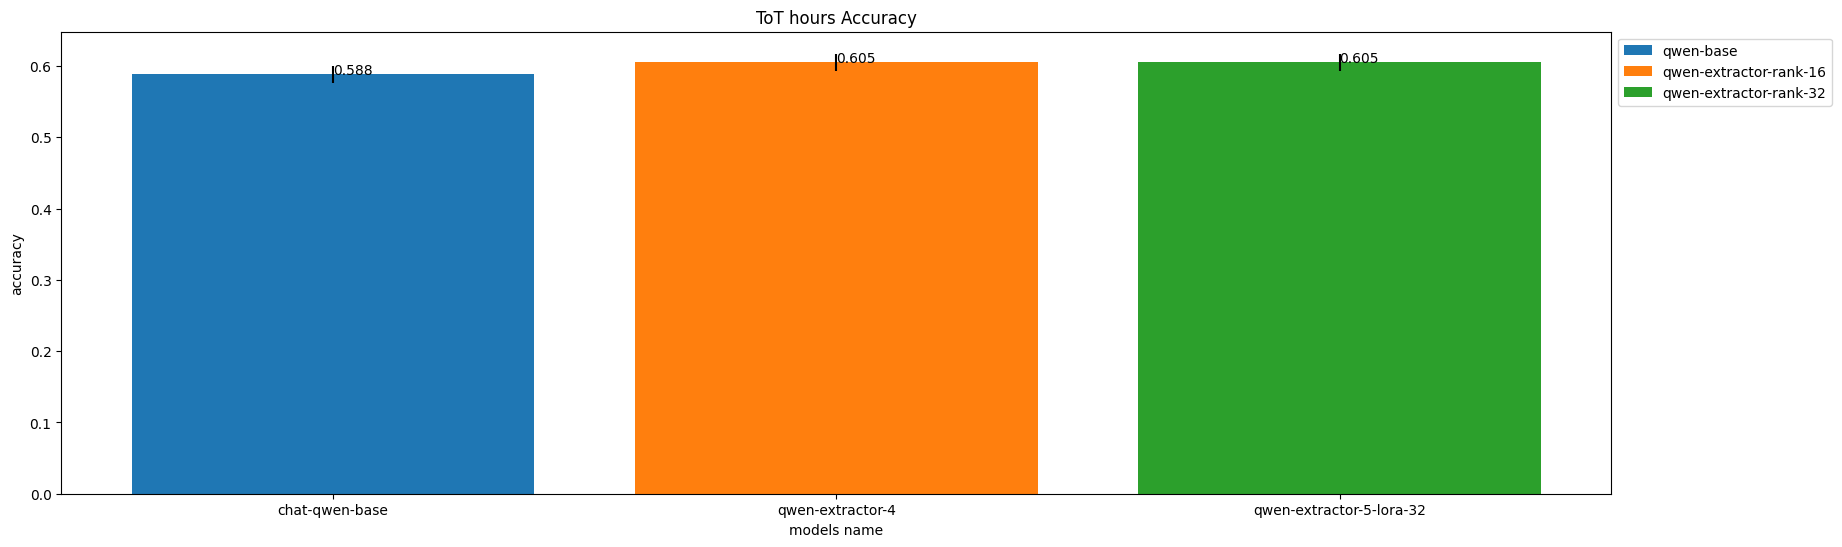

In [4]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []


for model in models:
    acc_media = round(df.loc[(df['model'] == model)  ]['tot_acc'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(models, media_group, yerr=CI_group, color=colors , label=labels)
add_labels(models,media_group)
plt.title("ToT hours Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

0.79 	+-0.03333484290104911
0.96 	+-0.016037653713485134
0.93 	+-0.020881693359836917
0.68 	+-0.03817725205220284
0.3 	+-0.03750462842724011
0.84 	+-0.03000370274179209
0.78 	+-0.03317174502866024
0.94 	+-0.019017316254812226
0.91 	+-0.022916676159699306
0.65 	+-0.03819446026616552
0.35 	+-0.03819446026616552
0.85 	+-0.028593332148683353
0.8 	+-0.032222398632334975
0.94 	+-0.019130989211262422
0.91 	+-0.02305365691430108
0.69 	+-0.037256604117387196
0.33 	+-0.03787845408900239
0.84 	+-0.029532316161143317
0.84 	+-0.029783354329590738
0.92 	+-0.022040065512717467
0.9 	+-0.02437222779732862
0.66 	+-0.038484460278492005
0.45 	+-0.040416767454404555
0.79 	+-0.033090030460150056


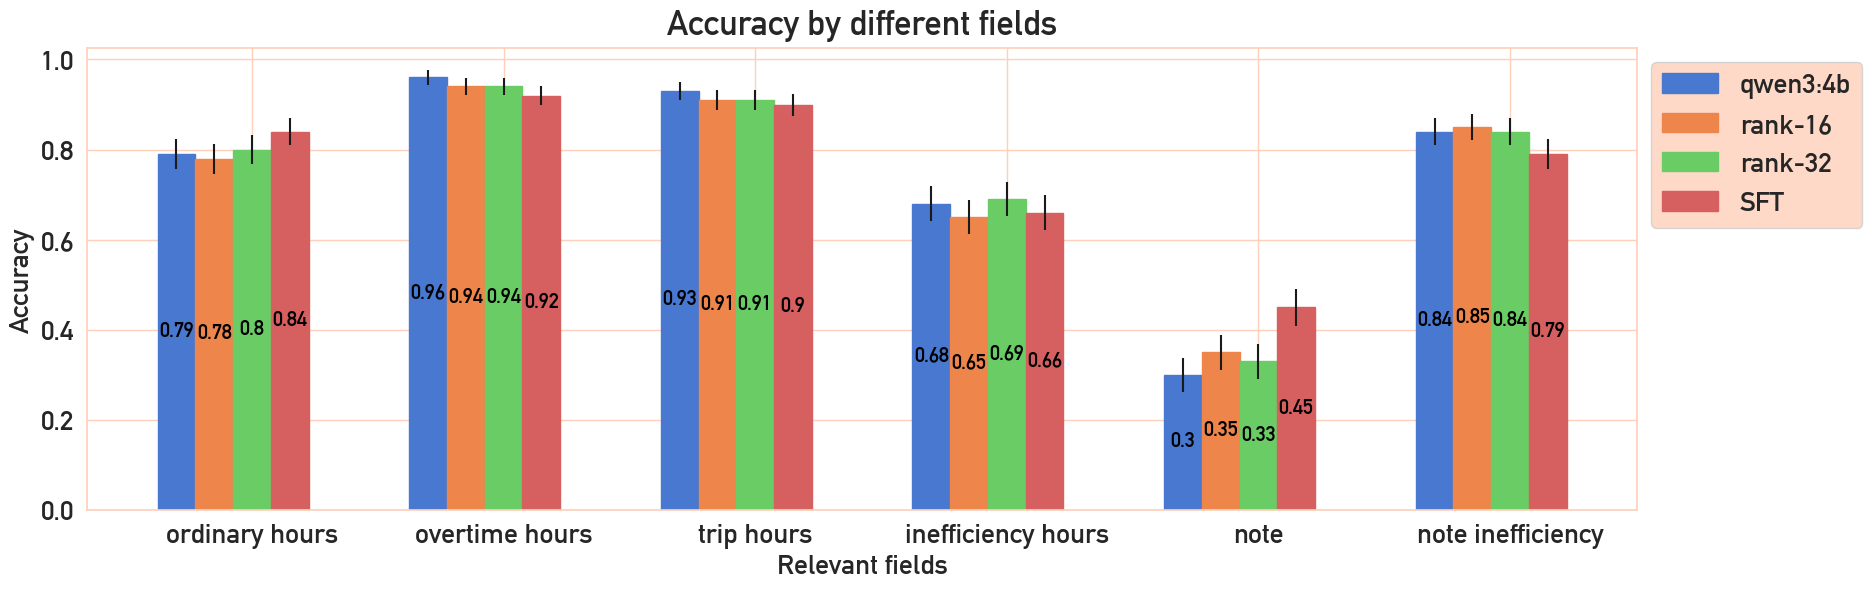

In [5]:
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label ,vals[i], vals[i], size=20)


fig, ax = plt.subplots(figsize=(20, 6))

fields=['ordinary hours', 'overtime hours', 'trip hours','inefficiency hours','note','note inefficiency']
columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
x = np.arange(len(fields))  # the label locations
width = 0.15  # the width of the bars
multiplier = 0


for model,label,color in zip(models,labels,colors):
    media_group = []
    CI_group = []
    
    
    for column in columns:
        g = df.loc[(df['model'] == model) & (df['failure_reason'].isna() == True)]
        acc_media = round(g[column].mean(),2)
        n = len(g)
        # intervallo di confidenza al 90 %
        CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    for media,CI in zip(media_group, CI_group):
        print(f"{media} \t+-{CI}")

    offset = width * multiplier

    rects = ax.bar(x + offset,media_group, width, yerr=CI_group, label=label,color=color, edgecolor=color)
    ax.bar_label(rects, padding=1, label_type='center',color="black",size=15, weight="bold")
    multiplier += 1
    ax.set_title(f"Accuracy by different fields", pad=10)
    ax.set_xlabel("Relevant fields")
    offset = width * 2
    ax.set_xticks(x + offset, fields)
    ax.set_ylabel("Accuracy")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")

plt.show()

0.786 	+-0.03356551997862753
0.957 	+-0.016602191401861973
0.929 	+-0.021019009723107766
0.681 	+-0.038145570735929515
0.303 	+-0.03761083047142139
0.839 	+-0.030079397861006017
change model
0.776 	+-0.03338601211195096
0.94 	+-0.019017316254812226
0.909 	+-0.02303097450544844
0.65 	+-0.03819446026616552
0.354 	+-0.038293720826518496
0.849 	+-0.028671604385611626
change model
0.799 	+-0.03228265858791059
0.939 	+-0.019279492091021748
0.909 	+-0.023168638460071948
0.687 	+-0.03735497173241464
0.327 	+-0.03779020808091113
0.842 	+-0.029382075071233596
change model
0.843 	+-0.02955545076940846
0.921 	+-0.02191378188547997
0.896 	+-0.024799598423184587
0.655 	+-0.038619279886650065
0.454 	+-0.040448108915968485
0.786 	+-0.033319013435896674
change model


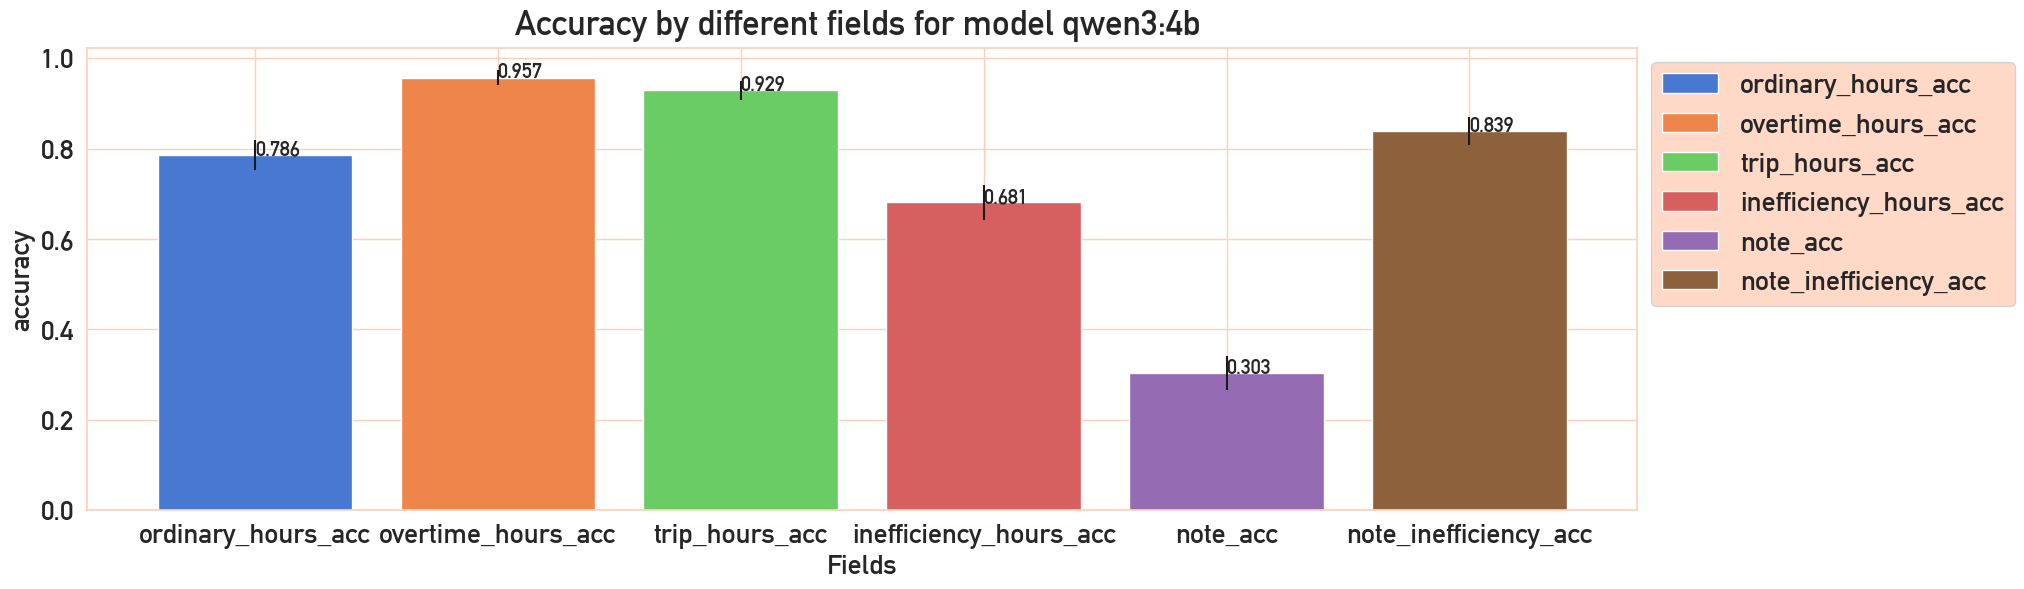

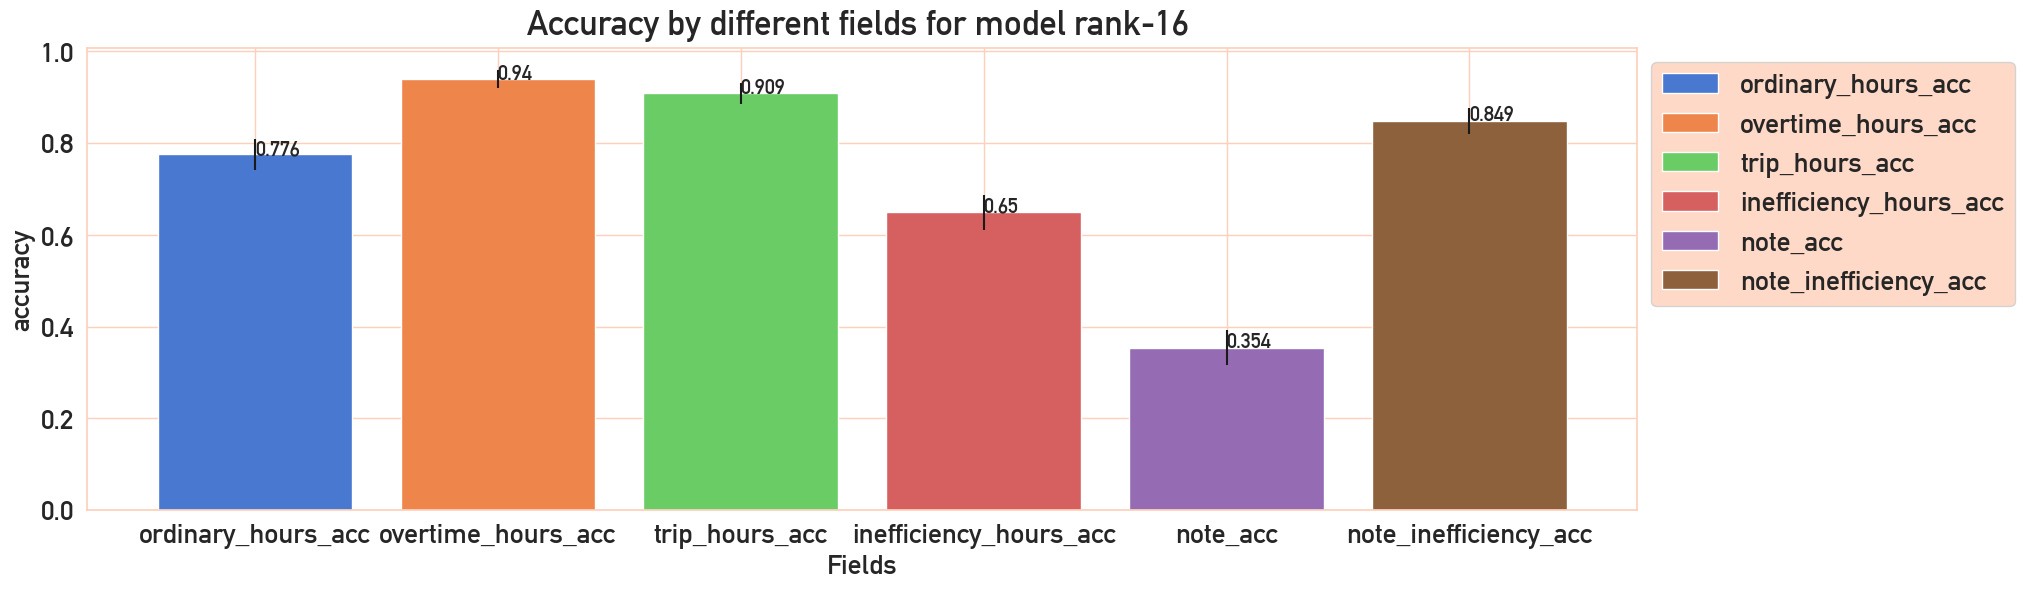

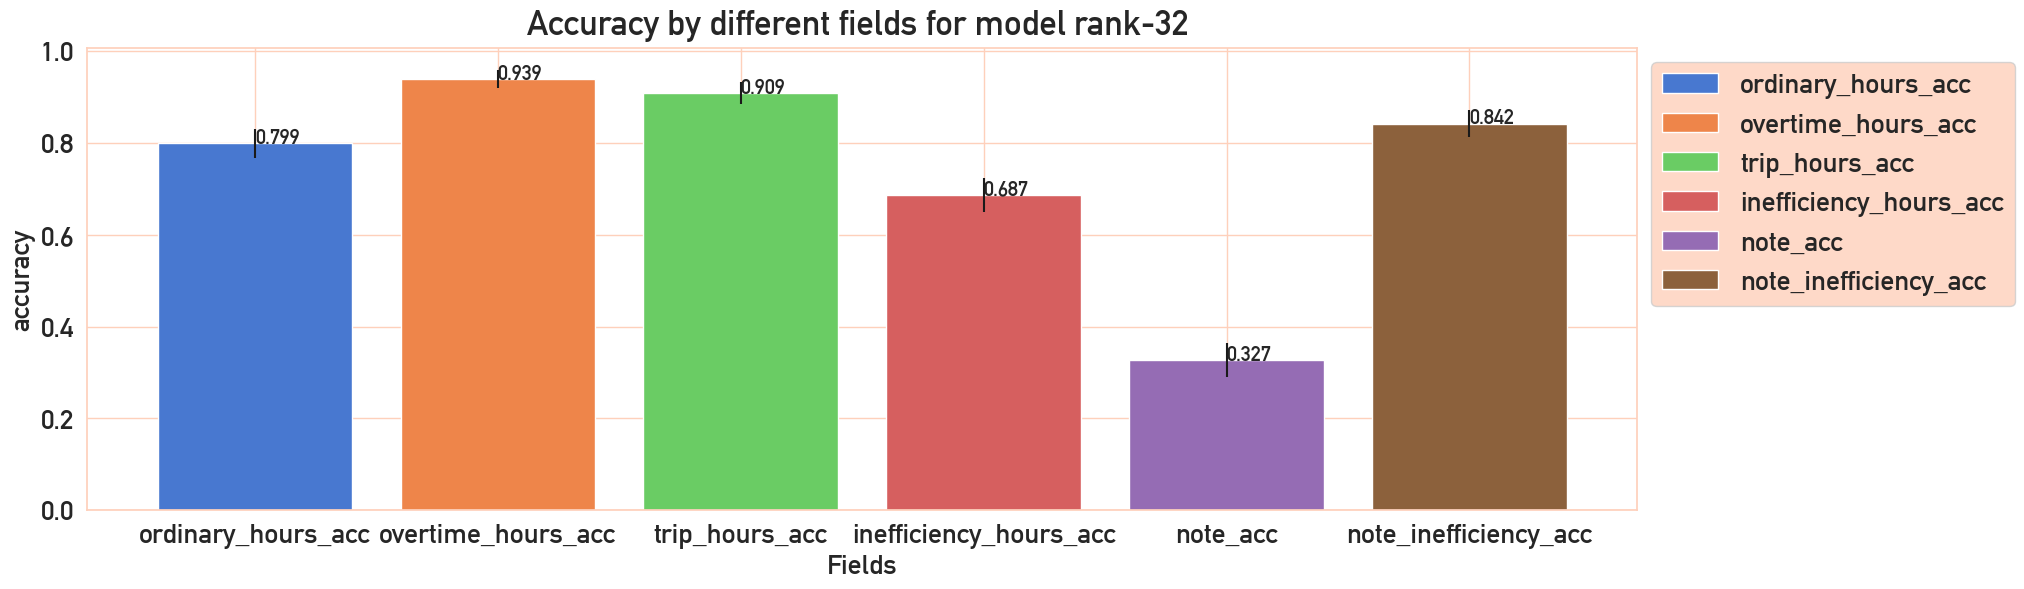

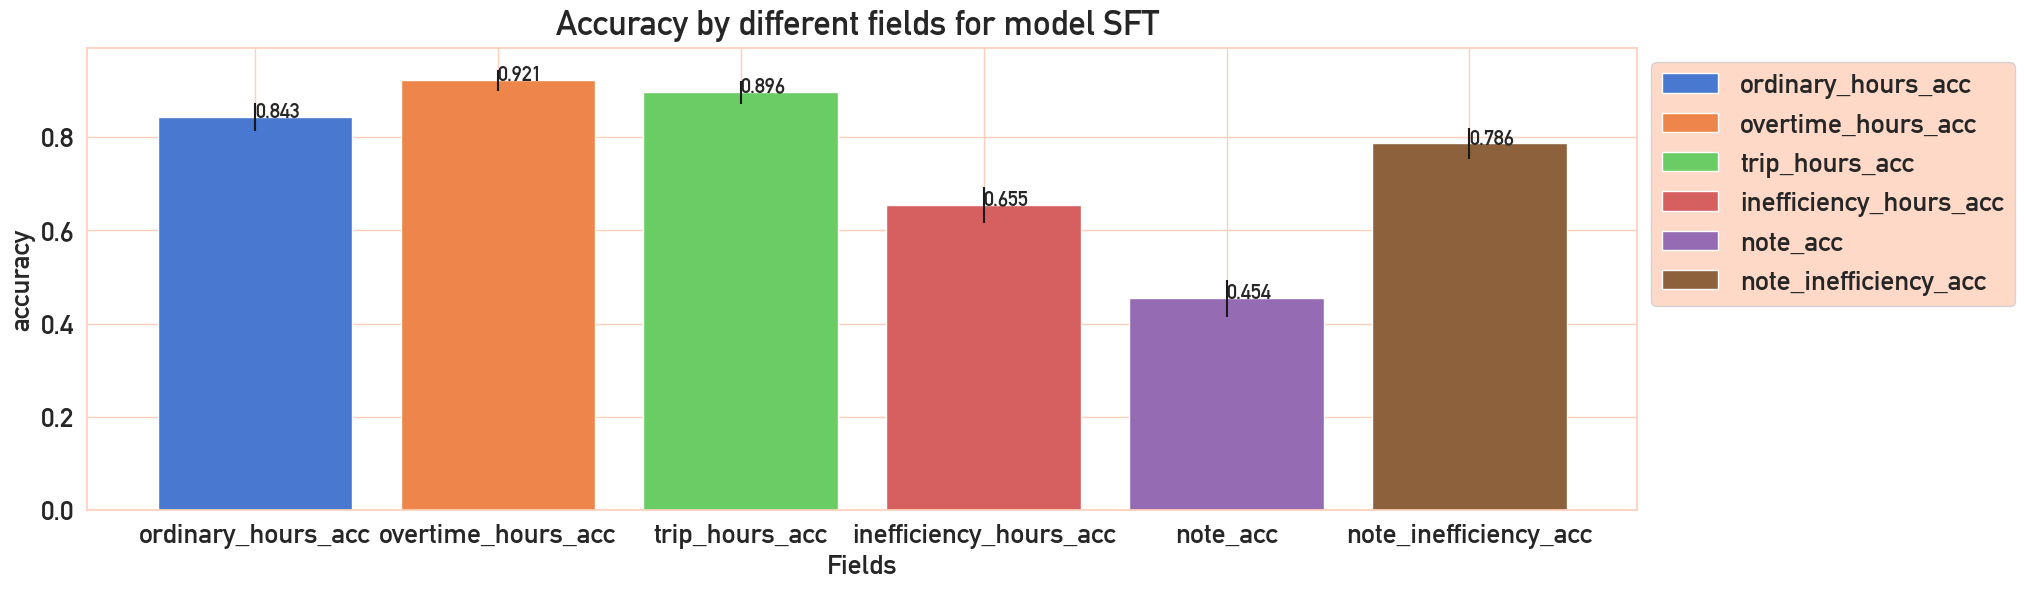

In [5]:
# chart per il display tot per ogni misurazione
# accuracy a tipi di schema
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i], size=15)

models = list(df[df['model'].str.contains(target)]['model'].unique())


for model,label in zip(models,labels):
    media_group = []
    CI_group = []
    columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
    fields=['ordinary_hours_acc', 'overtime_hours_acc', 'trip_hours_acc','inefficiency_hours_acc','note_acc','note_inefficiency_acc']
    for column in columns:
            
        g = df.loc[(df['model'] == model) & (df['failure_reason'].isna() == True)]

        acc_media = round(g[column].mean(),3)
        n = len(g)
        CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    for idx,(media,CI) in enumerate(zip(media_group, CI_group), start=1):
        print(f"{media} \t+-{CI}")
        if idx % 6 == 0:
            print(f"change model")
    plt.figure(figsize=(20,6))
    plt.bar(fields,media_group, yerr=CI_group, label=fields, color=colors)
    add_labels(fields,media_group)
    plt.title(f"Accuracy by different fields for model {label} ", pad=10)
    plt.xlabel("Fields")
    plt.xticks(fields)
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")


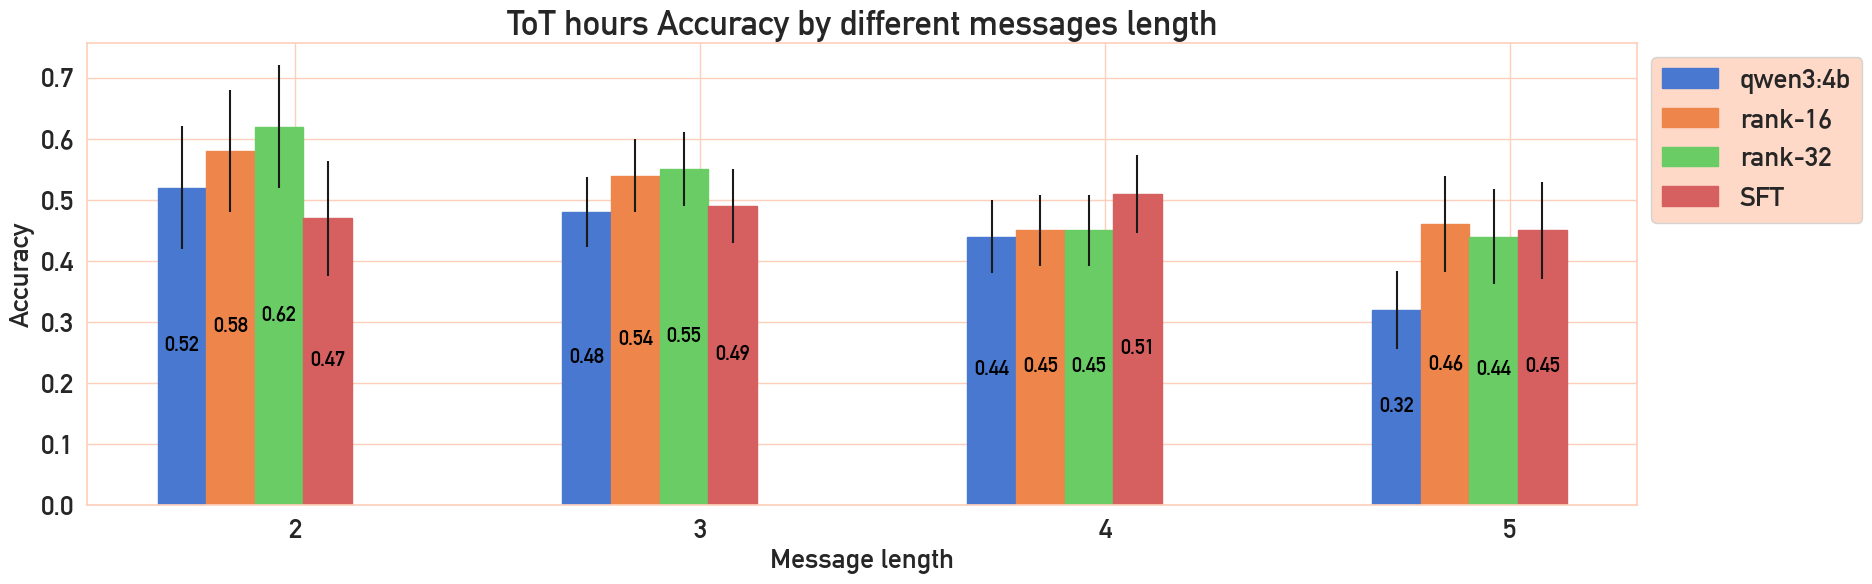

In [33]:
# accuracy a diversi livelli di lunghezza della lista messaggi
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i])

models = list(df[df['model'].str.contains(target)]['model'].unique())

l_msg = np.sort(df['L_MESSAGGI'].unique())
x = np.arange(len(l_msg))  # the label locations
width = 0.12  # the width of the bars
multiplier = 0
fig, ax = plt.subplots(figsize=(20,6))

for model,label,color in zip(models,labels,colors):
    media_group = []
    CI_group = []
    
    for length_m in l_msg:
        g = df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m) & (df['TYPE_EVAL'] == 'normal_w_correction')]
        
        acc_media = round(                                                                                                                                    
          (g['tot_acc'] * g['n_relevant_fields']).sum() / g['n_relevant_fields'].sum(),                                                                     
          2                                                                                                                                                 
        )                                                                                                                                                                                                                                                                                                      
        # effective n = total field evaluations (not number of rows)                                                                                          
        n = g['n_relevant_fields'].sum()
        # intervallo di confidenza al 90 %
        CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    offset = width * multiplier
    rects = ax.bar(x + offset, media_group, width, yerr=CI_group, label=label, color=color, edgecolor=color)
    ax.bar_label(rects, padding=1, label_type='center',color="black",size=15, weight="bold")
    multiplier += 1


n_metrics = len(l_msg)
center_offset = width * (n_metrics - 1) / 2 + 0.10

ax.set_title(f"ToT hours Accuracy by different messages length")
ax.set_xlabel("Message length")
ax.set_xticks(x + center_offset, l_msg)
ax.set_ylabel("Accuracy")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")

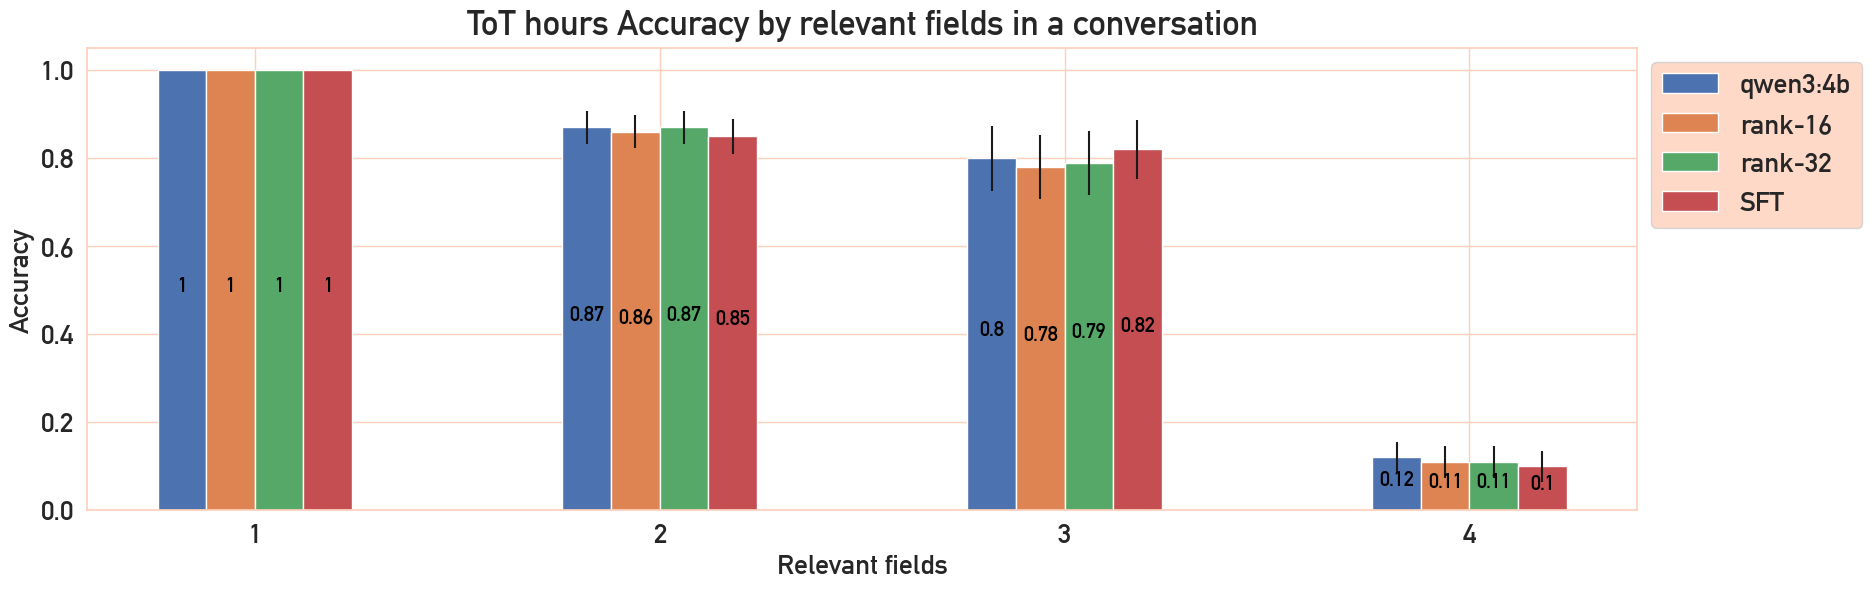

In [36]:
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i],size=15)

models = list(df[df['model'].str.contains(target)]['model'].unique())

n_fields = np.sort(df['n_relevant_fields'].unique())[1:]

fig, ax = plt.subplots(figsize=(20,6))

x = np.arange(len(n_fields))  # the label locations
width = 0.12  # the width of the bars
multiplier = 0

for model,label in zip(models,labels):
    media_group = []
    CI_group = []
    
    for n_field in n_fields:
        g = df.loc[(df['model'] == model)  & (df['n_relevant_fields'] == n_field)]
        acc_media = round(g['tot_acc'].mean(),2)
        n = len(g)
        # intervallo di confidenza al 90 %
        CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)
   

    
    offset = width * multiplier
    rects = ax.bar(x + offset, media_group, width, yerr=CI_group, label=label)
    ax.bar_label(rects, padding=3, label_type='center',color="black",size=15)
    multiplier += 1

n_metrics = len(n_fields)
center_offset = width * (n_metrics - 1) / 2 

ax.set_title(f"ToT hours Accuracy by relevant fields in a conversation", pad=10)
ax.set_xlabel("Relevant fields")
ax.set_xticks(x + center_offset, n_fields)
ax.set_ylabel("Accuracy")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")

plt.show()

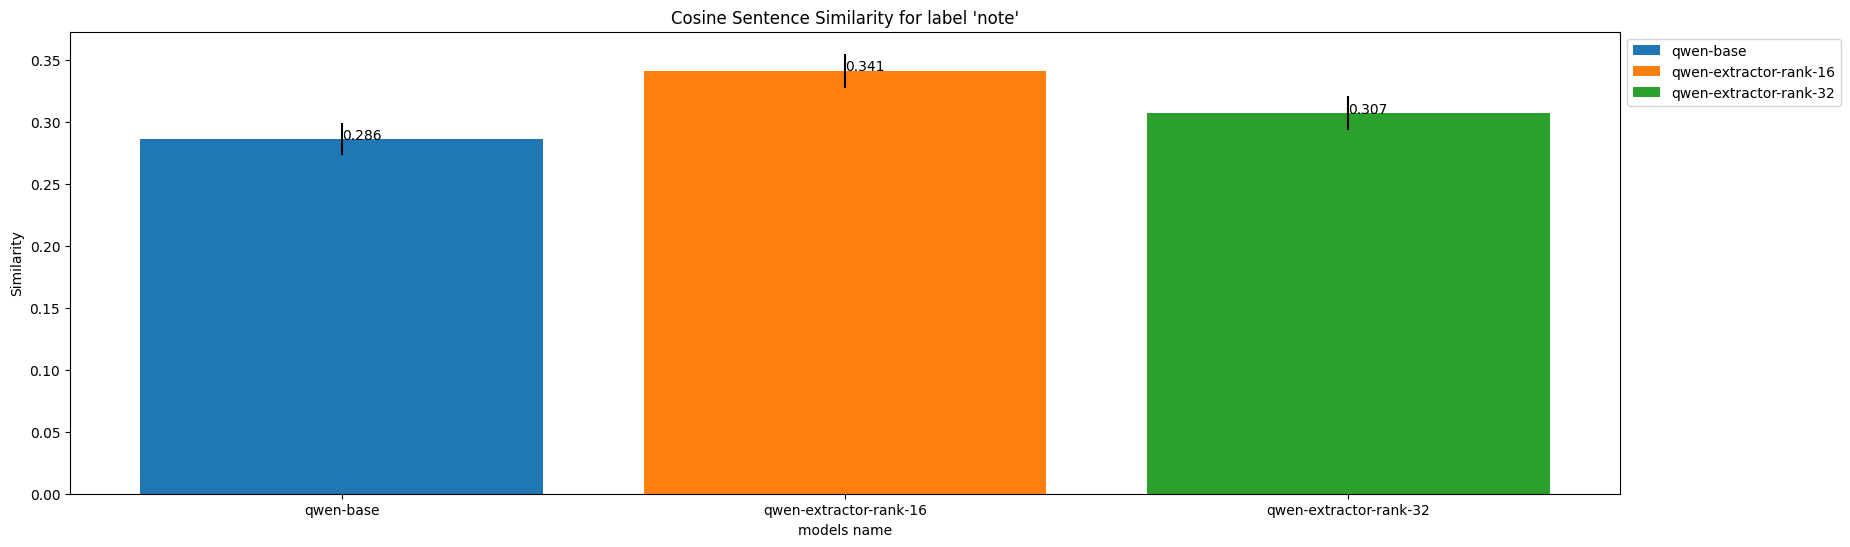

In [7]:
# cosine similarity del campo note con Sentence similarity
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])
media_group = []
CI_group = []
models = list(df[df['model'].str.contains(target)]['model'].unique())
for model in models:
    acc_media = round(df.loc[(df['model'] == model)  & (df['sentence_similarity_score_note'].isna() != True)]['sentence_similarity_score_note'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(labels, media_group, yerr=CI_group, color=colors, label=labels)
add_labels(models,media_group)
plt.title("Cosine Sentence Similarity for label 'note'")
plt.xlabel("models name")
plt.ylabel("Similarity")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

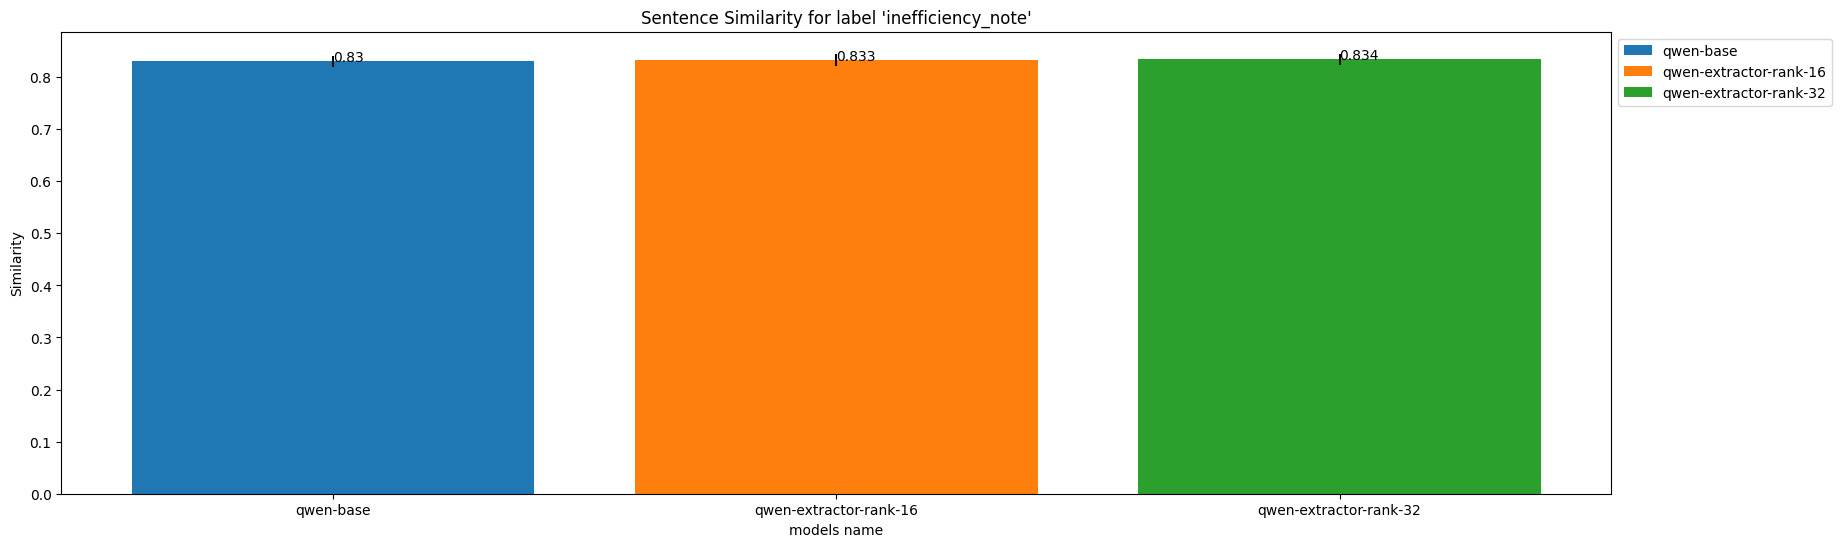

In [8]:
# cosine similarity campo inefficiency desciption
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])
media_group = []
CI_group = []
for model in models:
    acc_media = round(df.loc[(df['model'] == model) & (df['sentence_similarity_score_inefficiency'].isna() != True)]['sentence_similarity_score_inefficiency'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(labels, media_group, yerr=CI_group, color=colors, label=labels)
add_labels(models,media_group)
plt.title("Sentence Similarity for label 'inefficiency_note'")
plt.xlabel("models name")
plt.ylabel("Similarity")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

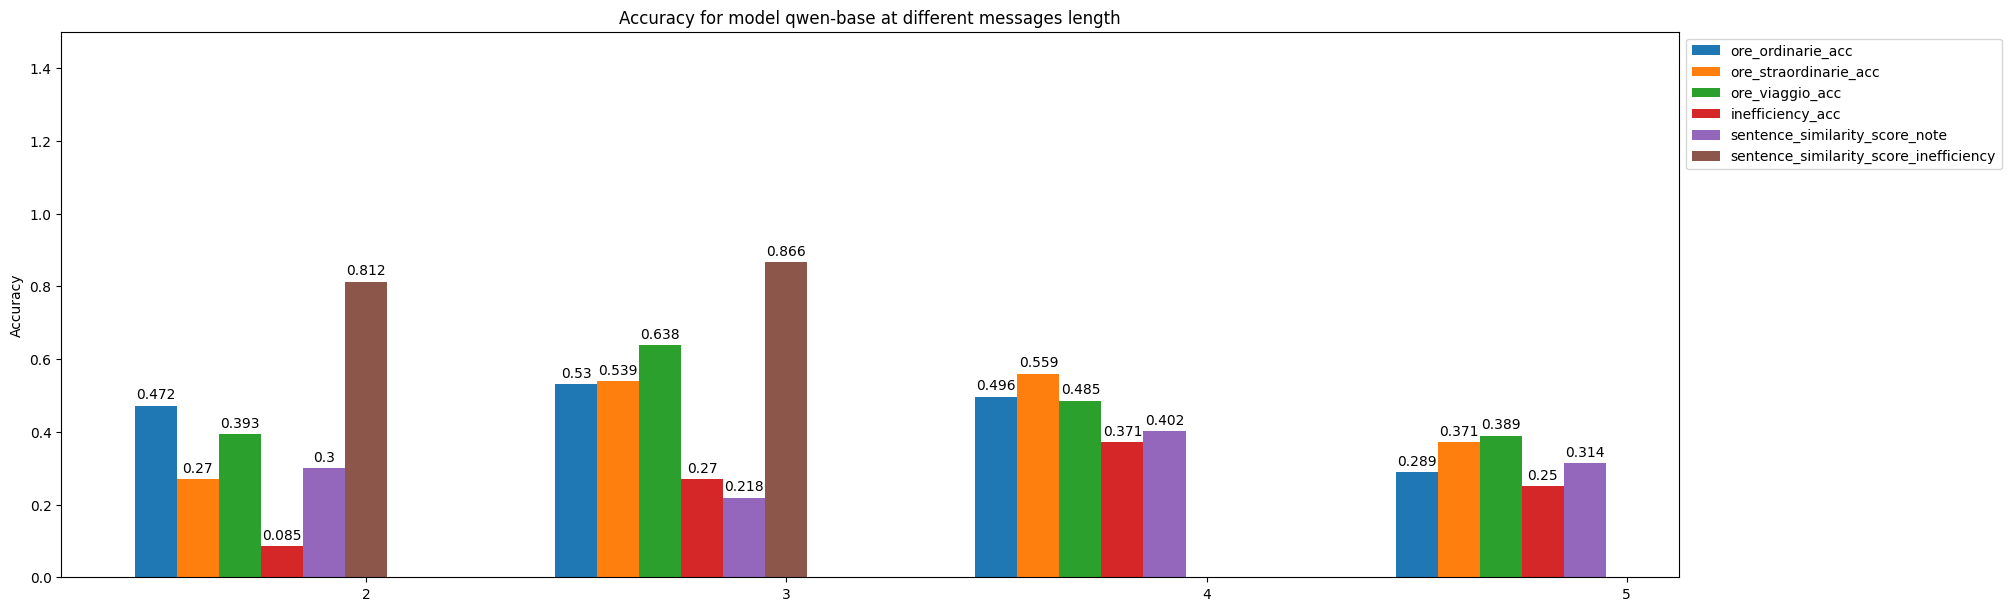

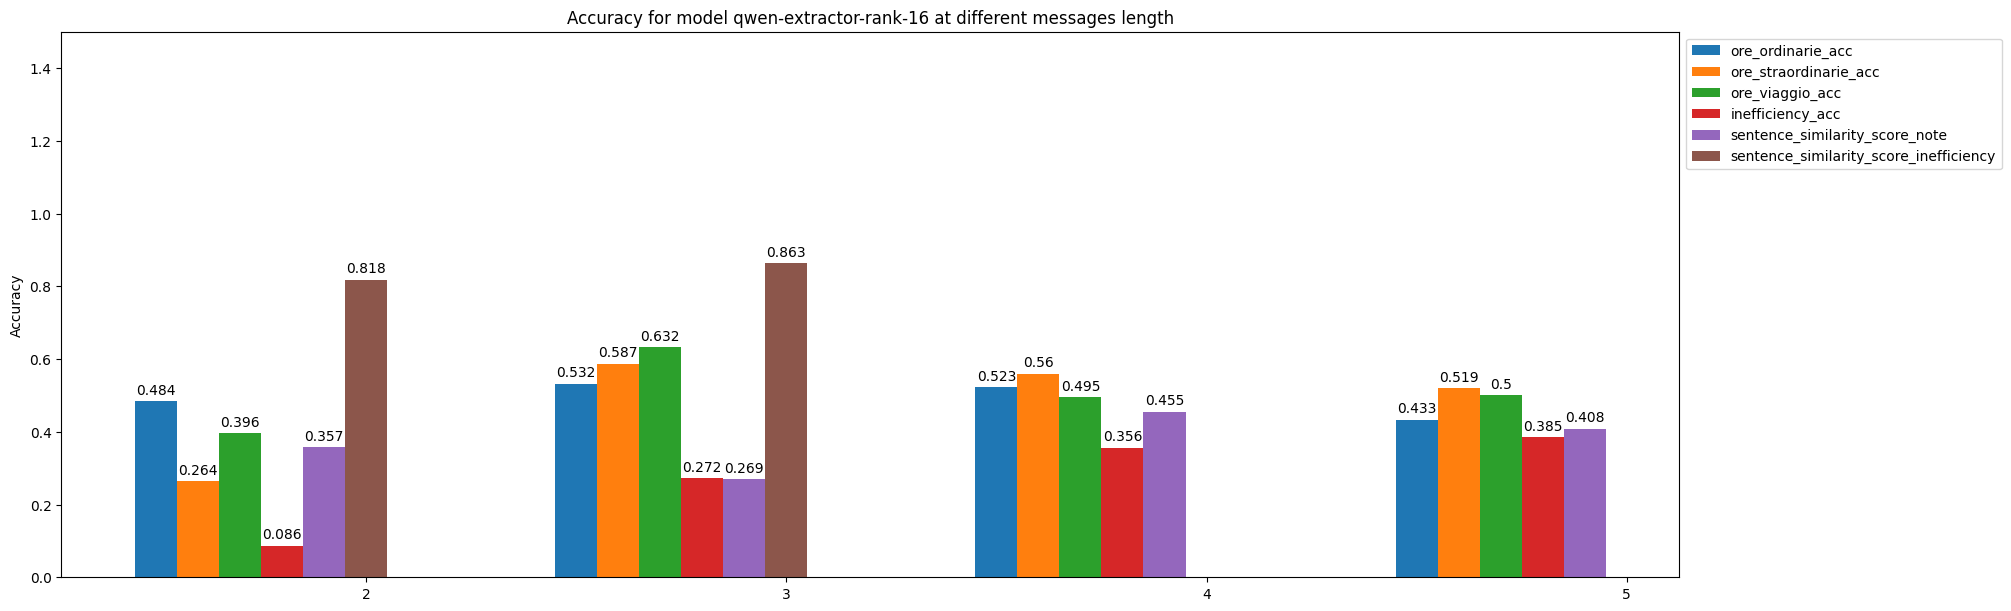

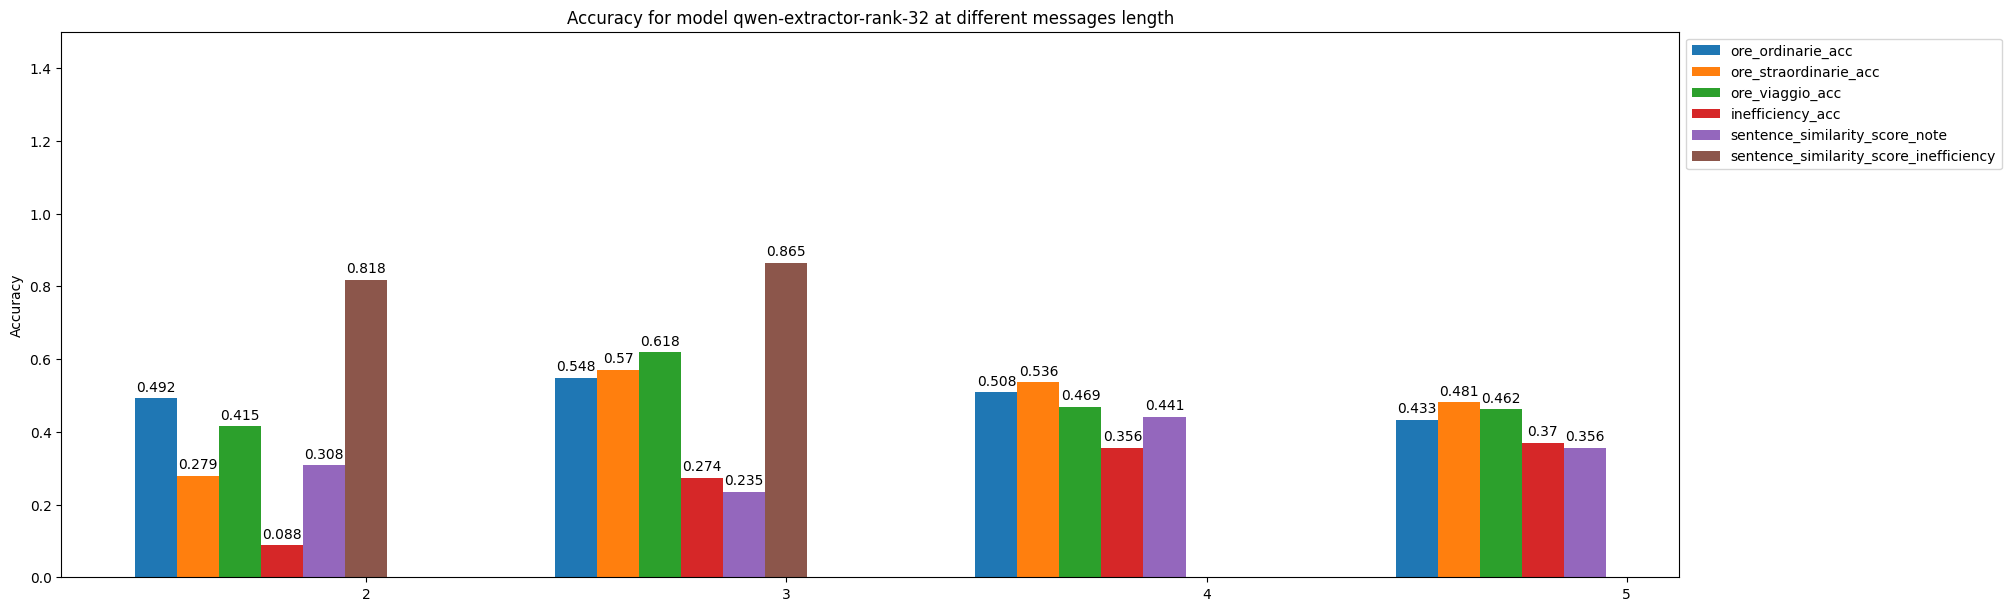

In [9]:
# chart per fare il display accuracy totale  al variare del flow

l_msg = np.sort(df['L_MESSAGGI'].unique())
for model,label in zip(models,labels):
    metric_means = {}
    columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
    # init il dict
    for column in columns:
        metric_means[column] = ()

    for length_m in l_msg:
        for column in columns:
            if column == 'sentence_similarity_score_inefficiency' or column == 'sentence_similarity_score_note':
                ris = (round(df.loc[(df['model'] == model) & (df[column].isna() != True) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
            else:
                ris = (round(df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
    
    x = np.arange(len(l_msg))  # the label locations
    width = 0.10  # the width of the bars
    multiplier = 0
    fig, ax = plt.subplots(figsize=(20,6), layout='constrained')
    for attribute, measurement in metric_means.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        
        # inseriamo l'accuracy media
        """ if attribute == 'ore_viaggio_acc':
            x_pos = x + offset
            for x in x_pos:
                ax.text(x, 1.1,'prova') """

        multiplier += 1
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy for model {label} at different messages length')
    ax.set_xticks(x + offset, l_msg)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    ax.set_ylim(0, 1.5)